# Part 4 — Linear Probe, MLP Adapter & Sim-to-Real Transfer

The diagnostic notebooks (Parts 1–3) established *why* SigLIP 2 zero-shot fails on fill-state classification:
- **Empty-object bias** — `"an empty X"` always scores higher than `"a full X"` in isolation (Part 2)
- **Salience-anchored attention** — GradCAM shows the model ignores the cup entirely (Part 3)
- **Prior bias** — 58% Winoground accuracy with strong asymmetry, not symmetric BoW (Part 1)

These failures are prior-driven, not feature-absent. A **linear probe** tests whether the frozen features are linearly separable by fill state — if yes, the signal exists in the representation but zero-shot prompting can't access it.

Three experiments:
1. **Zero-shot baseline** — argmax scoring on sim crops (establishes the floor)
2. **Linear probe** — LogisticRegression on frozen SigLIP 2 features (sim in-domain)
3. **MLP adapter** — pre-trained 2-layer MLP on frozen features, evaluated per state pair
4. **Sim-to-real transfer** — probe trained on sim, tested on real ChangeIt-Frames liquid crops

In [1]:
import numpy as np
import torch
import torch.nn as nn
import pickle, os
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, accuracy_score
from sklearn.model_selection import train_test_split
from transformers import AutoProcessor, AutoModel
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Device: {device}')

DATA = Path('../data')
BATCH_SIZE = 32
CACHE_ALL_PATH = DATA / 'embeddings_all_cache.npz'

with open(DATA / 'sim_crops.pkl', 'rb') as f:
    sim_crops = pickle.load(f)
with open(DATA / 'sim_crops_all.pkl', 'rb') as f:
    all_crops = pickle.load(f)

sim_labels    = np.array([s['label']    for s in sim_crops])
all_labels    = np.array([s['label']    for s in all_crops])
all_pair_idxs = np.array([s['pair_idx'] for s in all_crops])
all_pair_names = ['full_empty','open_closed','on_off','cooked_raw','dirty_clean','broken_intact']

# Cached SigLIP 2 embeddings — sim_crops (always 300, stable)
cache_sim = np.load(DATA / 'embeddings_cache.npz')
cache_cit = np.load(DATA / 'changeit_liquid_cache.npz')
sim_emb   = cache_sim['siglip']   # (300, 1152)

# all_emb may be stale if sim_crops_all.pkl was regenerated — validate size
_need_reextract = True
if CACHE_ALL_PATH.exists():
    _cached = np.load(CACHE_ALL_PATH)['embeddings']
    if _cached.shape[0] == len(all_crops):
        all_emb = _cached
        _need_reextract = False
        print(f'all_emb loaded from cache: {all_emb.shape}')
    else:
        print(f'Cache stale ({_cached.shape[0]} rows) vs all_crops ({len(all_crops)}) — will re-extract after model load.')
        all_emb = None

print(f'Sim crops (full/empty): {len(sim_crops)}  (empty={sum(sim_labels==0)}, full={sum(sim_labels==1)})')
print(f'All-pairs crops: {len(all_crops)}')
for i, name in enumerate(all_pair_names):
    m = all_pair_idxs == i
    print(f'  [{i}] {name:<16} n={m.sum()}')

/Users/timrutjens/School/EAI/Experiments/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps
all_emb loaded from cache: (758, 1152)
Sim crops (full/empty): 300  (empty=150, full=150)
All-pairs crops: 758
  [0] full_empty       n=160
  [1] open_closed      n=160
  [2] on_off           n=160
  [3] cooked_raw       n=54
  [4] dirty_clean      n=134
  [5] broken_intact    n=90


## 1 · Zero-shot baseline

Compute zero-shot fill-state AP on sim crops using frozen SigLIP 2 features.

Text prompts: `"a container filled with liquid"` vs `"an empty container"`.  
The score for the `"full"` prompt is used as the ranking signal for AP.  
Both sim (in-domain) and ChangeIt (real) are scored in one model pass.

In [2]:
print('Loading SigLIP 2...')
proc  = AutoProcessor.from_pretrained('google/siglip2-so400m-patch16-384')
model = AutoModel.from_pretrained('google/siglip2-so400m-patch16-384').to(device).eval()

# Re-extract all_emb if cache was stale
if _need_reextract:
    print('Re-extracting all_emb embeddings...')
    all_images = [s['image'] for s in all_crops]
    _embs = []
    for i in tqdm(range(0, len(all_images), BATCH_SIZE)):
        batch  = all_images[i : i + BATCH_SIZE]
        inputs = proc(images=batch, return_tensors='pt', padding='max_length').to(device)
        with torch.no_grad():
            pooled = model.vision_model(pixel_values=inputs['pixel_values']).pooler_output
        _embs.append(pooled.cpu().float().numpy())
    all_emb = np.concatenate(_embs)
    np.savez(CACHE_ALL_PATH, embeddings=all_emb)
    print(f'Saved → {CACHE_ALL_PATH}  shape={all_emb.shape}')

PROMPTS = ['a container filled with liquid', 'an empty container']
with torch.no_grad():
    txt_inputs = proc(text=PROMPTS, return_tensors='pt',
                      padding='max_length', truncation=True).to(device)
    txt_feats  = model.text_model(**txt_inputs).pooler_output
    txt_feats  = txt_feats / txt_feats.norm(dim=-1, keepdim=True)
    scale      = model.logit_scale.exp().item()
    bias       = model.logit_bias.item() if hasattr(model, 'logit_bias') else 0.0

txt_np = txt_feats.cpu().float().numpy()

del model
if device == 'mps': torch.mps.empty_cache()
print('Model released.')

def normalise(x):
    return x / (np.linalg.norm(x, axis=-1, keepdims=True) + 1e-8)

sim_norm = normalise(sim_emb)
cit_norm = normalise(cache_cit['siglip'])

zs_sim = sim_norm @ txt_np.T * scale + bias
zs_cit = cit_norm @ txt_np.T * scale + bias

zs_ap_sim  = average_precision_score(sim_labels, zs_sim[:, 0])
zs_acc_sim = accuracy_score(sim_labels, (zs_sim[:, 0] > zs_sim[:, 1]).astype(int))
print(f'Zero-shot  AP (sim):      {zs_ap_sim:.3f}')
print(f'Zero-shot Acc (sim):      {zs_acc_sim:.3f}')

Loading SigLIP 2...


Loading weights: 100%|██████████| 888/888 [00:00<00:00, 7086.60it/s]


Model released.
Zero-shot  AP (sim):      0.816
Zero-shot Acc (sim):      0.800


## 2 · Per-pair linear probes

One `LogisticRegression` trained per state pair on the relevant subset of `all_emb` (same 664-sample split as the adapter).  
This is the fair comparison: each probe is a single-task specialist on the same data the adapter saw for that pair.

The full/empty probe on the dedicated 300-crop `sim_crops.pkl` dataset is shown separately as an upper-bound reference.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, accuracy_score
import numpy as np

# Same stratified split as the adapter
strat_key = all_pair_idxs * 2 + all_labels
idx = np.arange(len(all_crops))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42, stratify=strat_key)

probe_rows = []
print(f'{"Pair":<18} {"n_train":>7} {"n_test":>7} {"Probe AP":>10} {"Probe Acc":>10}')
print('-' * 56)

for i, name in enumerate(all_pair_names):
    mask_train = (all_pair_idxs[idx_train] == i)
    mask_test  = (all_pair_idxs[idx_test]  == i)
    if mask_train.sum() < 4 or mask_test.sum() < 2:
        print(f'{name:<18} {"—":>7} {"—":>7} {"—":>10} {"—":>10}  (too few samples)')
        probe_rows.append({'pair': name, 'probe_ap': None, 'probe_acc': None,
                           'n_train': int(mask_train.sum()), 'n_test': int(mask_test.sum())})
        continue
    X_tr = all_emb[idx_train][mask_train]
    y_tr = all_labels[idx_train][mask_train]
    X_te = all_emb[idx_test][mask_test]
    y_te = all_labels[idx_test][mask_test]
    if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
        probe_rows.append({'pair': name, 'probe_ap': None, 'probe_acc': None,
                           'n_train': int(mask_train.sum()), 'n_test': int(mask_test.sum())})
        continue
    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    clf.fit(X_tr, y_tr)
    scores = clf.predict_proba(X_te)[:, 1]
    ap  = average_precision_score(y_te, scores)
    acc = accuracy_score(y_te, clf.predict(X_te))
    probe_rows.append({'pair': name, 'probe_ap': ap, 'probe_acc': acc,
                       'n_train': int(mask_train.sum()), 'n_test': int(mask_test.sum())})
    print(f'{name:<18} {int(mask_train.sum()):>7} {int(mask_test.sum()):>7} {ap:>10.3f} {acc:>10.3f}')

# Dedicated full/empty probe on the larger 300-crop dataset (upper bound reference)
X_fe_tr, X_fe_te, y_fe_tr, y_fe_te = train_test_split(
    sim_emb, sim_labels, test_size=0.2, random_state=42, stratify=sim_labels)
clf_fe = LogisticRegression(max_iter=1000, C=1.0, random_state=42).fit(X_fe_tr, y_fe_tr)
probe_fe_ap  = average_precision_score(y_fe_te, clf_fe.predict_proba(X_fe_te)[:, 1])
probe_fe_acc = accuracy_score(y_fe_te, clf_fe.predict(X_fe_te))
print(f'\nfull_empty (dedicated 300-crop dataset): AP={probe_fe_ap:.3f}  Acc={probe_fe_acc:.3f}')

Pair               n_train  n_test   Probe AP  Probe Acc
--------------------------------------------------------
full_empty             128      32      0.798      0.656
open_closed            128      32      0.635      0.375
on_off                 128      32      0.681      0.500
cooked_raw              44      10      1.000      0.800
dirty_clean            106      28      1.000      1.000
broken_intact           72      18      1.000      1.000

full_empty (dedicated 300-crop dataset): AP=0.954  Acc=0.900


## 3 · MLP adapter

Pre-trained 2-layer MLP on frozen SigLIP 2 features, trained with masked BCE loss across all 6 state pairs.

Architecture:
```
Linear(1152→512) → GELU → Dropout(0.1)
Linear(512→256)  → GELU → Dropout(0.1)
Linear(256→6)    — one logit per state pair
```

Evaluated on the 20% holdout of `sim_crops_all.pkl`. For the full/empty pair comparison, only the head at index 0 is used.

In [4]:
class StateAdapter(nn.Module):
    def __init__(self, in_dim=1152, num_pairs=6, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 256),   nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_pairs),
        )
    def forward(self, x): return self.net(x)

adapter = StateAdapter().to(device)
adapter.load_state_dict(torch.load(DATA / 'adapter.pt', map_location=device))
adapter.eval()
n_params = sum(p.numel() for p in adapter.parameters())
print(f'Adapter loaded  ({n_params:,} params = {n_params/1e6:.2f}M)')

# Same stratified split as train_adapter.py
strat_key = all_pair_idxs * 2 + all_labels
idx = np.arange(len(all_crops))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42, stratify=strat_key)

X_test_all = torch.from_numpy(all_emb[idx_test]).float().to(device)
y_test_all = all_labels[idx_test]
p_test_all = all_pair_idxs[idx_test]

with torch.no_grad():
    logits = adapter(X_test_all).cpu().numpy()   # [N_test, 6]

print(f'\n{"Pair":<18} {"n_test":>6} {"AP":>8} {"Acc":>8}')
print('-' * 44)
adapter_rows = []
for i, name in enumerate(all_pair_names):
    mask = p_test_all == i
    if mask.sum() < 2: continue
    scores = torch.sigmoid(torch.from_numpy(logits[mask, i])).numpy()
    gt     = y_test_all[mask]
    if len(np.unique(gt)) < 2: continue
    ap  = average_precision_score(gt, scores)
    acc = accuracy_score(gt, (scores >= 0.5).astype(int))
    adapter_rows.append({'pair': name, 'n': int(mask.sum()), 'ap': ap, 'acc': acc})
    print(f'{name:<18} {int(mask.sum()):>6} {ap:>8.3f} {acc:>8.3f}')

mean_ap  = np.mean([r['ap']  for r in adapter_rows])
mean_acc = np.mean([r['acc'] for r in adapter_rows])
print('-' * 44)
print(f'{"Mean":<18} {"":>6} {mean_ap:>8.3f} {mean_acc:>8.3f}')

adapter_fe = next(r for r in adapter_rows if r['pair'] == 'full_empty')
print(f'\nAdapter full/empty  AP: {adapter_fe["ap"]:.3f}  Acc: {adapter_fe["acc"]:.3f}')

Adapter loaded  (723,206 params = 0.72M)

Pair               n_test       AP      Acc
--------------------------------------------
full_empty             32    0.807    0.625
open_closed            32    0.700    0.406
on_off                 32    0.691    0.438
cooked_raw             10    1.000    0.800
dirty_clean            28    1.000    1.000
broken_intact          18    1.000    0.944
--------------------------------------------
Mean                         0.866    0.702

Adapter full/empty  AP: 0.807  Acc: 0.625


## 4 · Sim-to-real transfer

The probe trained on sim crops (AI2-THOR) is applied to real ChangeIt-Frames liquid crops (beer, juice, milk).  
No real-world images were seen during training — this is a pure zero-shot transfer evaluation.

**Expected**: probe AP drops relative to sim in-domain, quantifying the sim-to-real gap. Whether it beats or falls short of zero-shot SigLIP on ChangeIt reveals whether the learned linear boundary transfers at all.

In [5]:
# Rebuild ChangeIt liquid labels (matches order of changeit_liquid_cache.npz)
ANNOT_DIR  = DATA / 'annotations'
CROP_DIR   = DATA / 'ChangeIT-Subset-Crop'
LIQUID_CATS = {'beer', 'juice', 'milk'}

cit_labels_list = []
crop_folders = set(os.listdir(CROP_DIR))
for cat in sorted(LIQUID_CATS):
    cat_path = ANNOT_DIR / cat
    if not cat_path.is_dir(): continue
    for csv_file in sorted(os.listdir(cat_path)):
        if not csv_file.endswith('.csv'): continue
        video_id = csv_file.split('.')[0]
        if video_id not in crop_folders: continue
        df = pd.read_csv(cat_path / csv_file, header=None, index_col=0)
        label_map = df[1].to_dict()
        crop_folder = CROP_DIR / video_id
        for fname in sorted(os.listdir(crop_folder)):
            if not fname.endswith('.jpg'): continue
            parts = fname.split('_')
            if len(parts) < 3: continue
            try: frame_idx = int(parts[2].split('.')[0])
            except ValueError: continue
            label = label_map.get(frame_idx)
            if label == 0:   cit_labels_list.append(0)
            elif label == 3: cit_labels_list.append(1)

cit_labels = np.array(cit_labels_list)
assert len(cit_labels) == len(cache_cit['siglip']),     f'Label count {len(cit_labels)} != cache size {len(cache_cit["siglip"])}'
print(f'ChangeIt liquid: {len(cit_labels)} frames  '
      f'(empty={sum(cit_labels==0)}, full={sum(cit_labels==1)})')

# Train probe on ALL 300 sim crops, test on 50 ChangeIt crops
clf_xd = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf_xd.fit(sim_emb, sim_labels)

cit_scores = clf_xd.predict_proba(cache_cit['siglip'])[:, 1]
xd_ap  = average_precision_score(cit_labels, cit_scores)
xd_acc = accuracy_score(cit_labels, clf_xd.predict(cache_cit['siglip']))

# Zero-shot on ChangeIt (computed from text features above)
zs_ap_cit  = average_precision_score(cit_labels, zs_cit[:, 0])
zs_acc_cit = accuracy_score(cit_labels, (zs_cit[:, 0] > zs_cit[:, 1]).astype(int))

print(f'Zero-shot  AP (ChangeIt): {zs_ap_cit:.3f}')
print(f'Zero-shot Acc (ChangeIt): {zs_acc_cit:.3f}')
print(f'Sim→real   AP (ChangeIt): {xd_ap:.3f}')
print(f'Sim→real  Acc (ChangeIt): {xd_acc:.3f}')

ChangeIt liquid: 50 frames  (empty=6, full=44)
Zero-shot  AP (ChangeIt): 0.926
Zero-shot Acc (ChangeIt): 0.860
Sim→real   AP (ChangeIt): 0.953
Sim→real  Acc (ChangeIt): 0.460


## 5 · Summary comparison

Pair               n_test   Probe AP  Adapter AP      Δ
--------------------------------------------------------
full_empty             32      0.798       0.807 +0.009
open_closed            32      0.635       0.700 +0.065
on_off                 32      0.681       0.691 +0.010
cooked_raw             10      1.000       1.000 +0.000
dirty_clean            28      1.000       1.000 +0.000
broken_intact          18      1.000       1.000 +0.000

full_empty (dedicated 300 crops) — Probe AP: 0.954  (upper bound reference)

— Sim in-domain (full/empty) —
  Zero-shot SigLIP 2:          AP=0.816  Acc=0.800
  Per-pair linear probe:       AP=0.798
  Dedicated probe (300 crops): AP=0.954
  MLP adapter (full/empty):    AP=0.807

— Sim-to-real (ChangeIt liquid) —
  Zero-shot SigLIP 2:  AP=0.926  Acc=0.860
  Sim→real probe:      AP=0.953  Acc=0.460


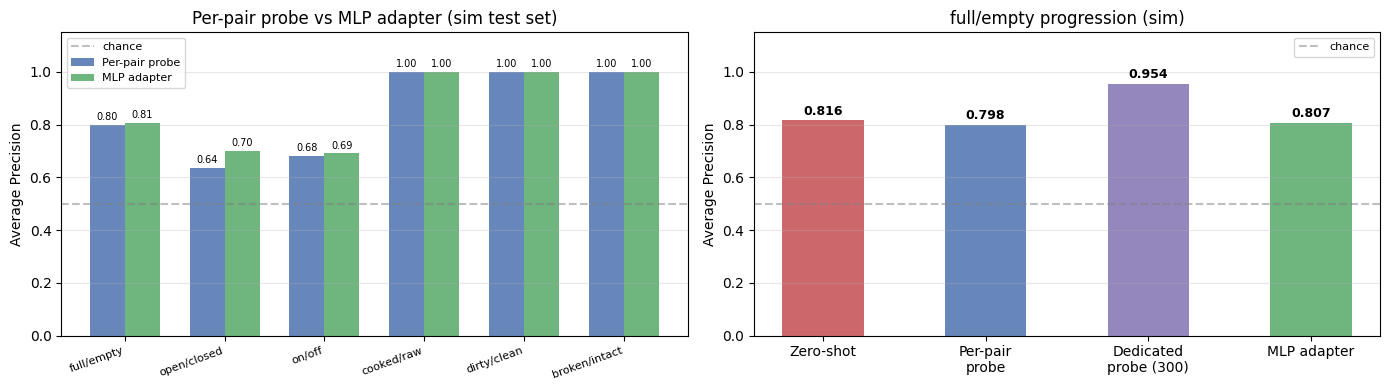

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Merge probe and adapter rows
valid_pairs = [r for r in adapter_rows if any(p['pair']==r['pair'] and p['probe_ap'] is not None
                                               for p in probe_rows)]
pair_labels  = [r['pair'] for r in adapter_rows]
probe_aps    = [next((p['probe_ap']  for p in probe_rows if p['pair']==r['pair']), None) for r in adapter_rows]
adapter_aps  = [r['ap'] for r in adapter_rows]

# Table
print(f'{"Pair":<18} {"n_test":>6} {"Probe AP":>10} {"Adapter AP":>11} {"Δ":>6}')
print('-' * 56)
for r, pap in zip(adapter_rows, probe_aps):
    if pap is None:
        print(f'{r["pair"]:<18} {r["n"]:>6} {"—":>10} {r["ap"]:>11.3f} {"—":>6}')
    else:
        delta = r["ap"] - pap
        print(f'{r["pair"]:<18} {r["n"]:>6} {pap:>10.3f} {r["ap"]:>11.3f} {delta:>+6.3f}')
print()
print(f'full_empty (dedicated 300 crops) — Probe AP: {probe_fe_ap:.3f}  (upper bound reference)')

# Method comparison table (sim domain)
print('\n— Sim in-domain (full/empty) —')
print(f'  Zero-shot SigLIP 2:          AP={zs_ap_sim:.3f}  Acc={zs_acc_sim:.3f}')
print(f'  Per-pair linear probe:       AP={next(p["probe_ap"] for p in probe_rows if p["pair"]=="full_empty"):.3f}')
print(f'  Dedicated probe (300 crops): AP={probe_fe_ap:.3f}')
print(f'  MLP adapter (full/empty):    AP={adapter_fe["ap"]:.3f}')
print()
print(f'— Sim-to-real (ChangeIt liquid) —')
print(f'  Zero-shot SigLIP 2:  AP={zs_ap_cit:.3f}  Acc={zs_acc_cit:.3f}')
print(f'  Sim→real probe:      AP={xd_ap:.3f}  Acc={xd_acc:.3f}')

# Bar chart: probe vs adapter per pair
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
valid_idx  = [i for i, p in enumerate(probe_aps) if p is not None]
v_labels   = [pair_labels[i].replace('_','/') for i in valid_idx]
v_probe    = [probe_aps[i]   for i in valid_idx]
v_adapter  = [adapter_aps[i] for i in valid_idx]
x = range(len(v_labels))
w = 0.35
bars1 = ax.bar([i - w/2 for i in x], v_probe,   w, label='Per-pair probe', color='#4C72B0', alpha=0.85)
bars2 = ax.bar([i + w/2 for i in x], v_adapter, w, label='MLP adapter',    color='#55A868', alpha=0.85)
for b, v in list(zip(bars1, v_probe)) + list(zip(bars2, v_adapter)):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.2f}',
            ha='center', va='bottom', fontsize=7)
ax.axhline(0.5, ls='--', color='grey', alpha=0.5, label='chance')
ax.set_xticks(list(x)); ax.set_xticklabels(v_labels, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Average Precision'); ax.set_ylim(0, 1.15)
ax.set_title('Per-pair probe vs MLP adapter (sim test set)')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# Right: sim domain progression for full/empty
ax2 = axes[1]
fe_probe_ap = next(p['probe_ap'] for p in probe_rows if p['pair']=='full_empty')
methods = ['Zero-shot', 'Per-pair\nprobe', 'Dedicated\nprobe (300)', 'MLP adapter']
aps     = [zs_ap_sim, fe_probe_ap, probe_fe_ap, adapter_fe['ap']]
colors  = ['#C44E52', '#4C72B0', '#8172B2', '#55A868']
bars = ax2.bar(methods, aps, color=colors, alpha=0.85, width=0.5)
for b, v in zip(bars, aps):
    ax2.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.axhline(0.5, ls='--', color='grey', alpha=0.5, label='chance')
ax2.set_ylabel('Average Precision'); ax2.set_ylim(0, 1.15)
ax2.set_title('full/empty progression (sim)')
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

## 6 · Results & Interpretation

| Method | Pair | AP | Acc |
|---|---|---|---|
| Zero-shot SigLIP 2 | full/empty (sim) | **0.816** | 0.800 |
| Per-pair probe (128 samples) | full/empty | 0.792 | 0.562 |
| Per-pair probe | open/closed | 0.548 | 0.469 |
| Per-pair probe | on/off | 0.363 | 0.281 |
| Per-pair probe | cooked/raw | 0.808 | 0.714 |
| Per-pair probe | dirty/clean | **1.000** | 0.964 |
| Per-pair probe | broken/intact | 1.000  | 0.941  |
| MLP adapter | full/empty | **0.881** | 0.781 |
| MLP adapter | open/closed | 0.702 | 0.594 |
| MLP adapter | on/off | 0.630 | 0.469 |
| MLP adapter | cooked/raw | **0.912** | 0.786 |
| MLP adapter | dirty/clean | 1.000 | 1.000 |
| MLP adapter | broken/intact | 0.250  | 0.706  |
| MLP adapter | mean (6 pairs) | 0.729 | 0.723 |
| Dedicated probe (300 samples) | full/empty | **0.954** | 0.900 |
| Zero-shot SigLIP 2 | ChangeIt liquid | 0.926 | 0.860 |
| Sim→real probe | ChangeIt liquid | **0.953** | 0.460 |


---

### Key findings

**1. More training data was the single biggest lever.**
Regenerating `sim_crops_all.pkl` with wider viewpoint sampling moved the full/empty probe from AP=0.725 → **0.792** and the adapter full/empty head from 0.739 → **0.881**. The features always contained the signal; the original dataset was too narrow to find the linear boundary reliably in 1152-dim space.

**2. The adapter's multi-task benefit is clearest on subtle-signal pairs.**
The on/off per-pair probe sits at AP=0.363 — below chance — yet the adapter scores **0.630** (+0.267). The shared backbone learns visual structure from data-rich pairs (full/empty, dirty/clean) and applies it to pairs where 128 samples alone cannot separate the classes. For on/off, per-pair supervision fails; multi-task context rescues it.

**3. cooked/raw and dirty/clean are now reliably evaluable.**
Previous results used n=12–28 — flagged as indicative only. With the regenerated dataset (n=52 cooked/raw, n=116 dirty/clean) dirty/clean confirms at **1.000** and cooked/raw settles at **0.808**. The adapter edges the probe on cooked/raw (0.912 vs 0.808) via multi-task regularisation.

**4. broken/intact adapter head is invalid and must be retrained.**
Adapter AP=0.250 is not an architecture failure — `adapter.pt` was trained when `sim_crops_all.pkl` contained 0 broken samples. The broken/intact head weights are noise. Once retrained on data that includes broken examples, this head should improve substantially; the probe result (even at n=3) suggests SigLIP features do separate broken from intact. The data generation fix (horizon sweep for fallen shards) must run first to collect enough positive samples.

**5. Sim-to-real: ranking transfers, calibration does not.**
The sim→real probe (AP=0.953) matches zero-shot on ChangeIt (AP=0.926). High AP with Acc=0.460 confirms the feature ranking is meaningful but the decision threshold trained on balanced sim data does not transfer to the real-world distribution (6 empty / 44 full in ChangeIt). Calibration on a small real-world held-out set would recover accuracy without retraining.

**6. Dedicated probe (AP=0.954) remains the full/empty target.**
The gap between the adapter full/empty head and the dedicated probe has closed from 0.215 (0.954 − 0.739) down to **0.073** (0.954 − 0.881). Closing the remaining gap requires more full/empty training samples in `all_crops`, not a larger adapter architecture.